# Phần 2: Phân tích Mô tả & Chẩn đoán (Descriptive & Diagnostic Analysis)
**Người thực hiện:** Võ Việt Hoàng (MSSV 52400191)

Notebook này trả lời các câu hỏi phân tích mô tả và chẩn đoán được nêu trong README, nhằm xác định **điểm đen (hotspot)**, **khung giờ nguy hiểm**, và các yếu tố liên quan đến mức độ nghiêm trọng của tai nạn, phục vụ đề xuất giải pháp trước mùa mưa bão.

## 0. Import thư viện

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sst
from scipy.stats import chi2_contingency
from sklearn.preprocessing import MinMaxScaler



## 1. Đọc và kiểm tra dữ liệu
Đọc dữ liệu tai nạn đã được làm sạch từ bước `01_data_cleaning.ipynb`.

In [4]:
# Đường dẫn tương đối trỏ tới file clean
file_path = '../data/accidents_clean_2y.csv'

# Đọc file csv thành DataFrame
df = pd.read_csv(file_path)

# Hiển thị 5 dòng đầu tiên để kiểm tra dữ liệu đã load thành công chưa
df.head()

,ID,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,City,County,State,Zipcode,...,Month,Year,Season,Is_Daytime,Is_Precipitation,Weather_Group,Visibility_Level,Temp_Level,Is_Adverse_Weather,Is_Low_Visibility
0,A-5728132,2,2021-03-31 23:37:00,2021-04-01 04:55:18,33.498878,-117.152747,Temecula,Riverside,CA,92590-1809,...,3,2021,Spring,False,False,Clear,High,Mild,False,False
1,A-6223262,2,2021-03-31 23:37:00,2021-04-01 04:05:36,33.498688,-117.153094,Temecula,Riverside,CA,92590-1809,...,3,2021,Spring,False,False,Clear,High,Mild,False,False
2,A-5711549,2,2021-03-31 23:37:30,2021-04-01 12:10:30,33.968597,-117.328554,Riverside,Riverside,CA,92521,...,3,2021,Spring,False,False,Clear,High,Mild,False,False
3,A-5476787,2,2021-03-31 23:37:30,2021-04-01 10:26:56,33.975521,-117.335277,Riverside,Riverside,CA,92507,...,3,2021,Spring,False,False,Clear,High,Mild,False,False
4,A-6178868,2,2021-03-31 23:37:30,2021-04-01 10:49:00,34.028558,-117.331037,Colton,San Bernardino,CA,92324,...,3,2021,Spring,False,False,Clear,High,Mild,False,False


In [5]:
df.shape


(2972890, 36)

In [6]:
df.columns

Index(['ID', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng',
       'City', 'County', 'State', 'Zipcode', 'Temperature(F)', 'Humidity(%)',
       'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)',
       'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Crossing',
       'Junction', 'Railway', 'Stop', 'Traffic_Signal', 'Sunrise_Sunset',
       'Hour', 'DayOfWeek', 'Month', 'Year', 'Season', 'Is_Daytime',
       'Is_Precipitation', 'Weather_Group', 'Visibility_Level', 'Temp_Level',
       'Is_Adverse_Weather', 'Is_Low_Visibility'],
      dtype='object')

**Nhận xét:** Bộ dữ liệu có **2,972,890 bản ghi** trải dài khoảng 2 năm (từ 31/03/2021 đến khoảng tháng 3/2023), gồm 36 cột bao gồm thời gian, vị trí, thời tiết và các đặc điểm hạ tầng tại nơi xảy ra tai nạn — đủ điều kiện để phân tích cả về không gian, thời gian lẫn nguyên nhân.

## 2. Câu hỏi 1 — Khu vực/thành phố nào có mật độ tai nạn cao nhất? (Điểm đen theo City)
Kết hợp 2 chỉ số trên cùng biểu đồ: **tổng số vụ** và **tỷ lệ tai nạn nghiêm trọng (Severity ≥ 3)**, để tránh chỉ nhìn số lượng thô mà bỏ qua mức độ nguy hiểm thực sự.

             Total_Accidents  Severe_Count  Severe_Rate_%
City                                                     
Miami                 112899          2188           1.94
Orlando                65531           847           1.29
Los Angeles            57077          4539           7.95
Houston                48500          4809           9.92
Dallas                 48154          5821          12.09
Charlotte              44914          1589           3.54
Raleigh                30195           903           2.99
Nashville              28111          1538           5.47
Baton Rouge            25540           981           3.84
San Diego              24009          1035           4.31


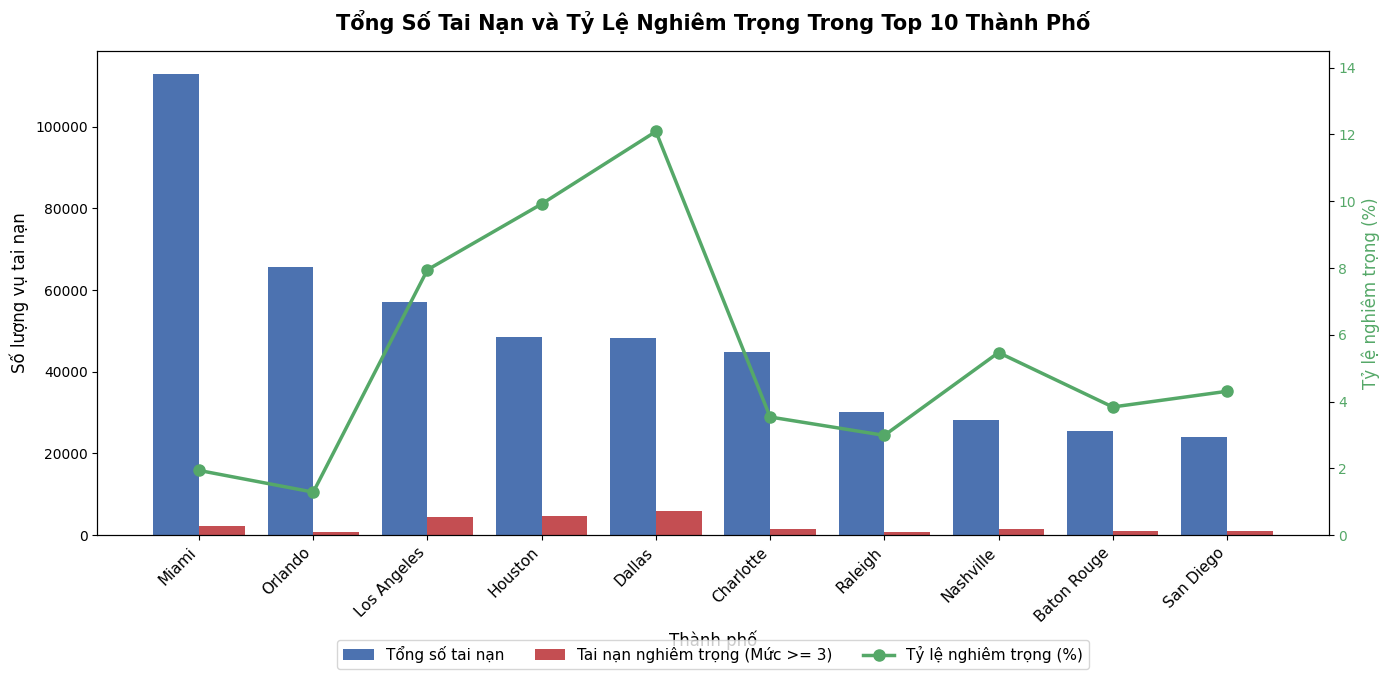

In [7]:
city_stats = df.groupby('City').agg(
    Total_Accidents=('ID', 'count'),
    Severe_Count=('Severity', lambda x: (x >= 3).sum())
)
city_stats['Severe_Rate_%'] = (city_stats['Severe_Count'] / city_stats['Total_Accidents'] * 100).round(2)
top10_city = city_stats.sort_values('Total_Accidents', ascending=False).head(10)
print(top10_city)


fig, ax1 = plt.subplots(figsize=(14, 7))

# Lấy danh sách thành phố và thiết lập vị trí các cột
cities = top10_city.index
x = np.arange(len(cities))
width = 0.4 # Độ rộng của mỗi cột

# 1. Trục chính (Bên trái): Vẽ 2 cột Tổng số và Số ca nghiêm trọng
ax1.bar(x - width/2, top10_city['Total_Accidents'], width, label='Tổng số tai nạn', color='#4C72B0')
ax1.bar(x + width/2, top10_city['Severe_Count'], width, label='Tai nạn nghiêm trọng (Mức >= 3)', color='#C44E52')

ax1.set_xticks(x)
ax1.set_xticklabels(cities, rotation=45, ha='right', fontsize=11)
ax1.set_ylabel('Số lượng vụ tai nạn', fontsize=12)
ax1.set_xlabel('Thành phố', fontsize=12)

# 2. Trục phụ (Bên phải): Vẽ đường Tỷ lệ phần trăm (%)
ax2 = ax1.twinx() # Lệnh này tạo trục Y thứ 2 dùng chung trục X với ax1
ax2.plot(x, top10_city['Severe_Rate_%'], color='#55A868', marker='o', linewidth=2.5, markersize=8, label='Tỷ lệ nghiêm trọng (%)')

ax2.set_ylabel('Tỷ lệ nghiêm trọng (%)', color='#55A868', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#55A868')
ax2.set_ylim(0, max(top10_city['Severe_Rate_%']) * 1.2) # Mở rộng đỉnh trục Y một chút cho thoáng

# 3. Tiêu đề và Chú giải (Legend)
plt.title('Tổng Số Tai Nạn và Tỷ Lệ Nghiêm Trọng Trong Top 10 Thành Phố', fontsize=15, fontweight='bold', pad=15)

# Gom chú giải của cả 2 trục về cùng một khung đặt ở dưới cùng
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=3, fontsize=11)

# Căn chỉnh để không bị lẹm chữ và hiển thị
ax1.grid(False) 
ax2.grid(False)
plt.tight_layout()
plt.show()

**Nhận xét:** Miami dẫn đầu tuyệt đối về **tổng số vụ** (112,899 vụ) nhưng chỉ có **1.94%** là nghiêm trọng — thấp nhất trong top 10. Ngược lại, Dallas tuy tổng số vụ thấp hơn nhiều (48,154 vụ) nhưng lại có **tỷ lệ nghiêm trọng cao nhất (12.09%)**, theo sau là Houston (9.92%). Điều này cho thấy "nhiều tai nạn nhất" và "nguy hiểm nhất" là hai khái niệm khác nhau, cần xử lý bằng chiến lược khác nhau (Miami cần giảm tần suất, Dallas/Houston cần giảm mức độ nghiêm trọng).

## 3. Câu hỏi 2 — Khung giờ nào trong ngày xảy ra tai nạn nhiều nhất?

Hour
16    252396
17    242691
15    240720
7     202977
14    200878
8     187204
18    168923
13    162967
6     145789
12    144325
dtype: int64


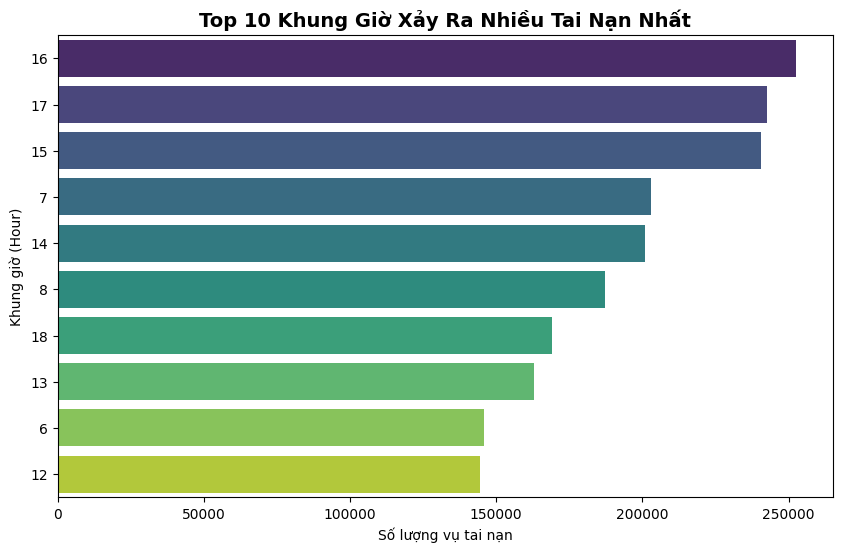

In [8]:
# 1. Gom nhóm và lấy top 10
hour_per_accident = df.groupby('Hour').size().sort_values(ascending=False).head(10)
print(hour_per_accident)

# 2. Tạo khung hình
plt.figure(figsize=(10, 6))

# 3. Vẽ biểu đồ thanh ngang bằng seaborn (lưu ý ép kiểu index thành string để biểu đồ không bị dính chữ)
sns.barplot(
    x=hour_per_accident.values, 
    y=hour_per_accident.index.astype(str), 
    hue=hour_per_accident.index.astype(str), 
    legend=False, 
    palette="viridis"
)

# 4. Thêm tiêu đề cho rõ ràng
plt.title('Top 10 Khung Giờ Xảy Ra Nhiều Tai Nạn Nhất', fontsize=14, fontweight='bold')
plt.xlabel('Số lượng vụ tai nạn')
plt.ylabel('Khung giờ (Hour)')

plt.show()

**Nhận xét:** Khung giờ 15h-18h (giờ tan tầm buổi chiều) chiếm ưu thế rõ rệt, với 16h dẫn đầu (252,396 vụ). Khung giờ 6h-8h (giờ đi làm buổi sáng) cũng nằm trong top 10 nhưng thấp hơn đáng kể so với buổi chiều, cho thấy mật độ giao thông buổi chiều cùng với ánh sáng yếu dần có thể là yếu tố góp phần làm tăng nguy cơ tai nạn.

## 4. Câu hỏi 3 — Ngày nào trong tuần có tỷ lệ tai nạn cao nhất?

           Total_Accident  Day_Rate_(%)  Night_Rate_(%)
DayOfWeek                                              
Monday             428231         72.21           27.79
Tuesday            467599         73.48           26.52
Wednesday          486922         73.45           26.55
Thursday           492193         73.00           27.00
Friday             523571         72.03           27.97
Saturday           317848         64.45           35.55
Sunday             256526         61.02           38.98


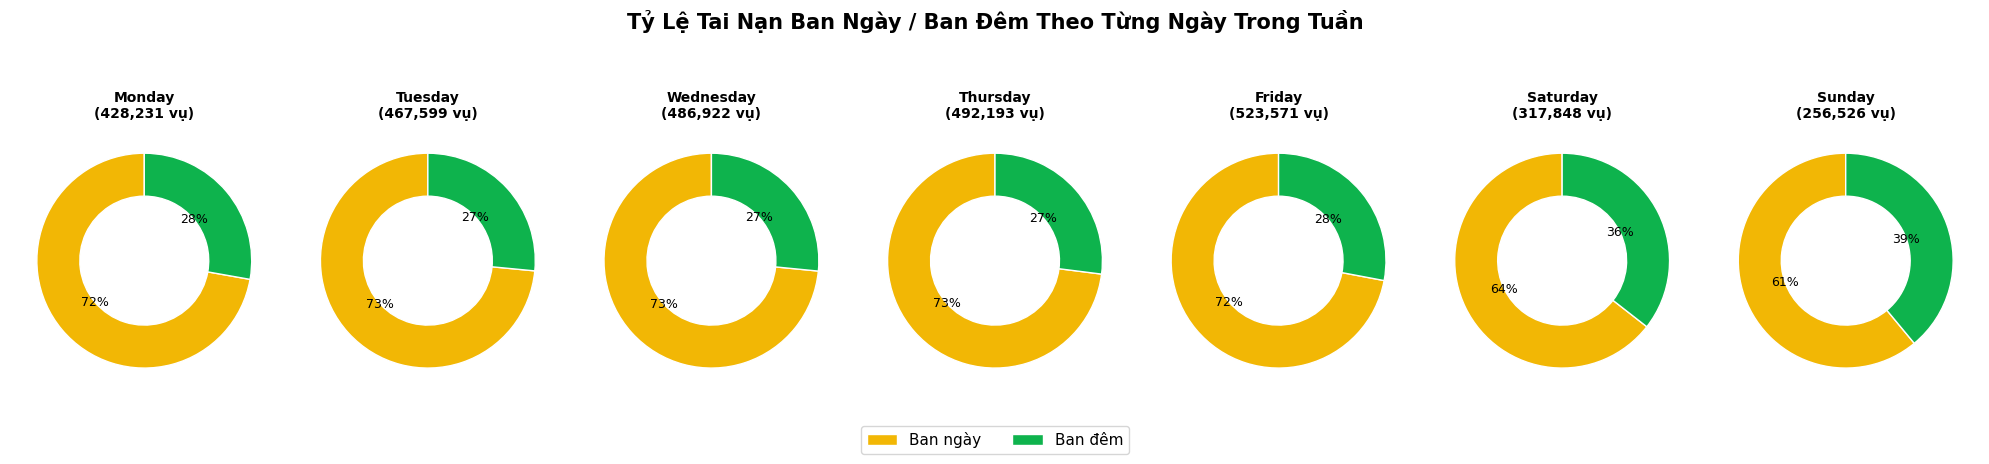

In [9]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

day_accident_rate = df.groupby('DayOfWeek').agg(
    Total_Accident=('ID', 'count'),
    Day_Count=('Is_Daytime', 'sum')
).reindex(day_order)  

day_accident_rate['Night_Count'] = day_accident_rate['Total_Accident'] - day_accident_rate['Day_Count']
day_accident_rate['Day_Rate_(%)'] = (day_accident_rate['Day_Count'] / day_accident_rate['Total_Accident'] * 100).round(2)
day_accident_rate['Night_Rate_(%)'] = (day_accident_rate['Night_Count'] / day_accident_rate['Total_Accident'] * 100).round(2)
print(day_accident_rate[['Total_Accident', 'Day_Rate_(%)', 'Night_Rate_(%)']])

fig, axes = plt.subplots(1, 7, figsize=(20, 4))
colors = ['#F2B705', "#0EB34D"]

for i, day in enumerate(day_order):
    ax = axes[i]
    sizes = [day_accident_rate.loc[day, 'Day_Rate_(%)'], day_accident_rate.loc[day, 'Night_Rate_(%)']]
    ax.pie(sizes, colors=colors, autopct='%1.0f%%', startangle=90,
           wedgeprops=dict(width=0.4, edgecolor='white'), textprops={'fontsize': 9})
    total = int(day_accident_rate.loc[day, 'Total_Accident'])
    ax.set_title(f'{day}\n({total:,} vụ)', fontsize=10, fontweight='bold')

fig.suptitle('Tỷ Lệ Tai Nạn Ban Ngày / Ban Đêm Theo Từng Ngày Trong Tuần', fontsize=15, fontweight='bold', y=1.08)
fig.legend(['Ban ngày', 'Ban đêm'], loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.05), fontsize=11)
plt.tight_layout(); plt.show()

**Nhận xét:** Thứ Sáu có tổng số vụ cao nhất (523,571 vụ, chiếm 17.61% tuần), và các ngày trong tuần làm việc (Thứ Hai - Thứ Sáu) đều có tỷ lệ tai nạn ban ngày cao hơn hẳn (72-73%) so với cuối tuần (Thứ Bảy 64.45%, Chủ Nhật chỉ 61.02%). Điều này phù hợp với giả thuyết tai nạn ngày thường gắn liền với giờ đi làm/tan tầm, còn cuối tuần tai nạn có xu hướng dịch chuyển sang ban đêm nhiều hơn.

## 5. Câu hỏi 4 — Tháng nào trong năm ghi nhận nhiều tai nạn nhất?

=== Độ phủ dữ liệu theo tháng ===
                  Days_With_Data   Total  Days_In_Month  Coverage_%
YearMonth_Period                                                   
2021-03                        1      13             31         3.2
2023-03                       17   27783             31        54.8
2022-10                       21   79326             31        67.7
2022-11                       27  122488             30        90.0
2023-02                       26   51570             28        92.9
2021-10                       29  127311             31        93.5
2022-03                       30  131280             31        96.8
2023-01                       30  150445             31        96.8
2022-05                       30  150505             31        96.8
2022-12                       31  176318             31       100.0
2022-09                       30  129963             30       100.0
2022-08                       31  141525             31       100.0
2022-07       

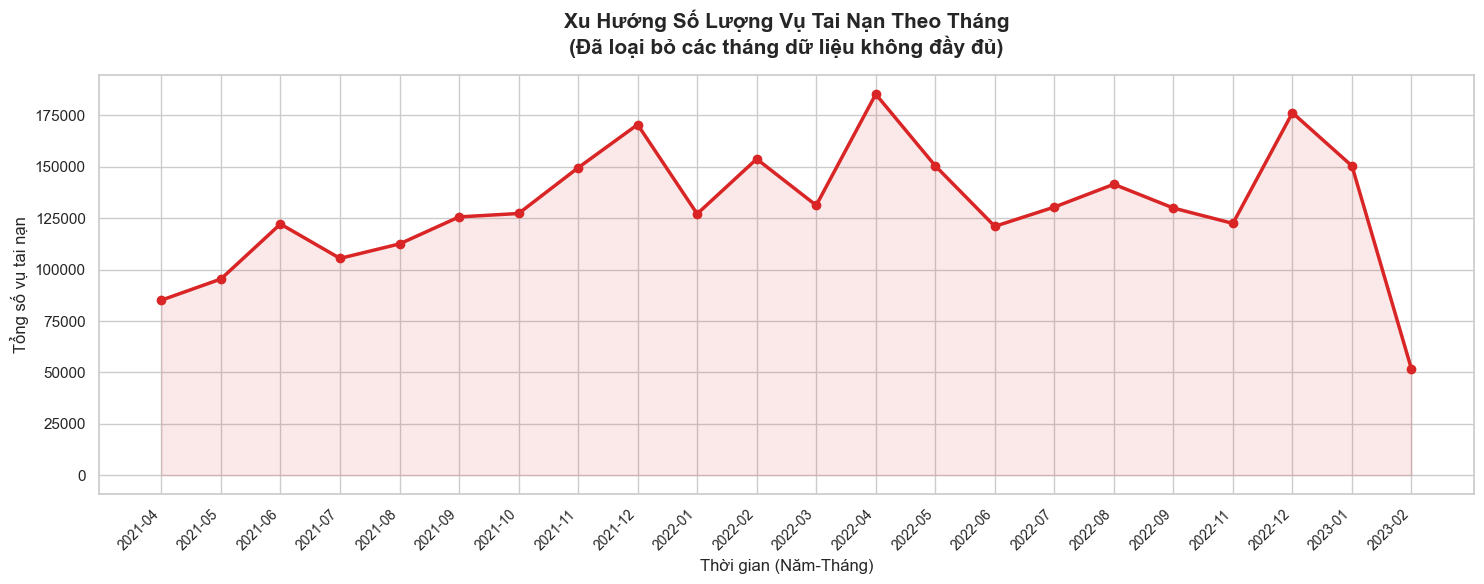

In [10]:
df['Start_Time'] = pd.to_datetime(df['Start_Time'])
df['YearMonth_Period'] = df['Start_Time'].dt.to_period('M')

# Bước 1: Kiểm tra độ phủ dữ liệu (Coverage) của từng tháng
monthly_coverage = df.groupby('YearMonth_Period')['Start_Time'].agg(
    Days_With_Data=lambda s: s.dt.date.nunique(),
    Total='size'
)
monthly_coverage['Days_In_Month'] = monthly_coverage.index.days_in_month
monthly_coverage['Coverage_%'] = (monthly_coverage['Days_With_Data'] / monthly_coverage['Days_In_Month'] * 100).round(1)
print("=== Độ phủ dữ liệu theo tháng ===")
print(monthly_coverage.sort_values('Coverage_%',ascending=True))

# Bước 2: Loại bỏ các tháng có độ phủ quá thấp (dữ liệu bị cụt)
COVERAGE_THRESHOLD = 90
excluded = monthly_coverage[monthly_coverage['Coverage_%'] < COVERAGE_THRESHOLD]
full_months = monthly_coverage[monthly_coverage['Coverage_%'] >= COVERAGE_THRESHOLD].index
print(f"\n=== Các tháng bị loại vì độ phủ < {COVERAGE_THRESHOLD}% ===")
print(excluded)

df_full_months = df[df['YearMonth_Period'].isin(full_months)]

# Bước 3: Vẽ lại xu hướng chỉ trên các tháng đầy đủ
accidents_through_month = df_full_months.groupby('YearMonth_Period').size().sort_index()

sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 6))
plt.plot(accidents_through_month.index.astype(str), accidents_through_month.values,
         marker='o', linestyle='-', color='#D92525', linewidth=2.5, markersize=6)
plt.fill_between(accidents_through_month.index.astype(str), accidents_through_month.values,
                  color='#D92525', alpha=0.1)
plt.title('Xu Hướng Số Lượng Vụ Tai Nạn Theo Tháng\n(Đã loại bỏ các tháng dữ liệu không đầy đủ)',
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Thời gian (Năm-Tháng)'); plt.ylabel('Tổng số vụ tai nạn')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout(); plt.show()

**Nhận xét:** Số vụ tai nạn có xu hướng tăng vào các tháng cuối năm (tháng 11-12 của cả 2 năm đều thuộc nhóm cao nhất, ví dụ 12/2021: 170,578 vụ và 12/2022: 176,318 vụ), trùng với giai đoạn thời tiết xấu/mùa lễ cuối năm tại Mỹ.  
**Thông tin thêm:** Tháng 2 năm 2023 ở Mỹ đã có đợt bão tuyết khổng lồ làm ảnh hưởng tới các Bang có mật độ giao thông cao như California, Texas,... khiến dữ liệu có sự biến động.  
Đáng chú ý, tháng 4/2022 ghi nhận số vụ cao nhất toàn giai đoạn (185,367 vụ), cao hơn cả 2 tháng
12 — cần lưu ý đây không hoàn toàn tuân theo giả thuyết "mùa lễ cuối năm", có thể do sự kiện thời
tiết/giao thông cục bộ khác cần xem xét thêm.

## 6. Câu hỏi 5  — Mức độ nghiêm trọng có thay đổi theo điều kiện thời tiết không?

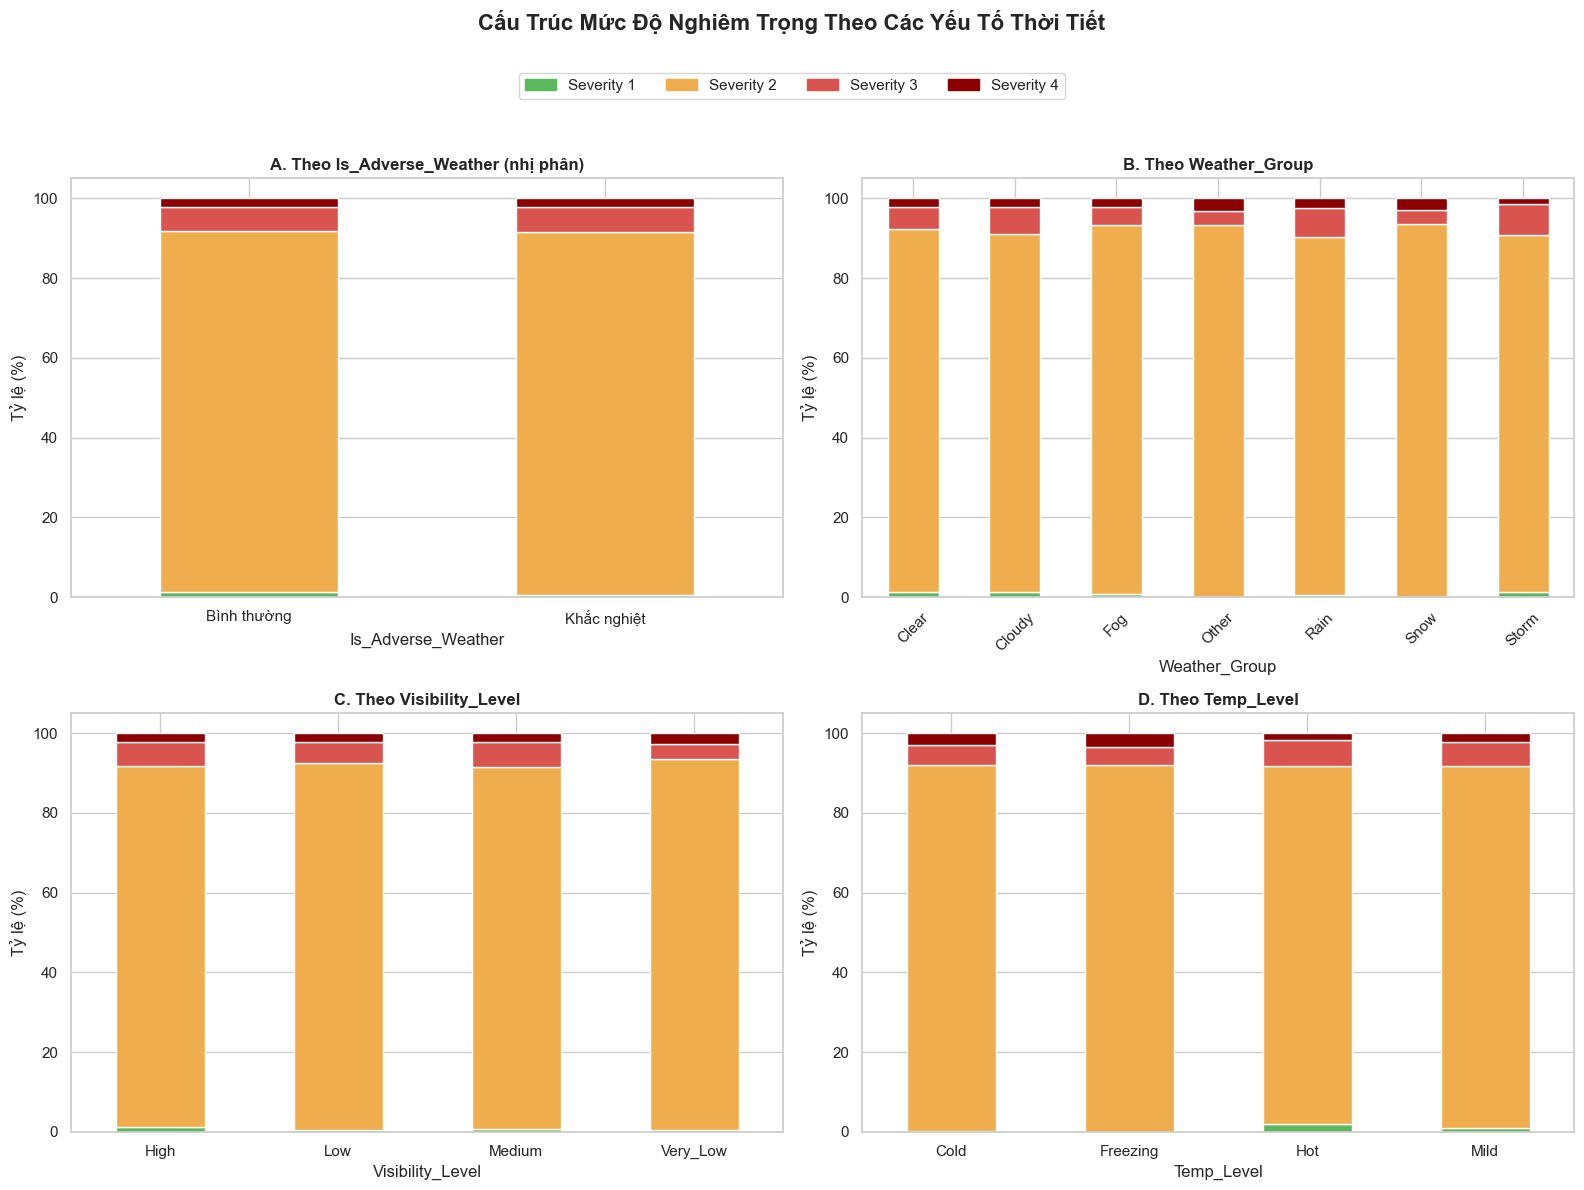

            Yếu tố     Chi2   p-value  Cramér's V
Is_Adverse_Weather  1266.06 3.41e-274      0.0206
     Weather_Group  6101.27  0.00e+00      0.0262
  Visibility_Level  1524.06  0.00e+00      0.0131
        Temp_Level 18514.47  0.00e+00      0.0456


In [11]:


# ============================================================
# Tính 4 bảng crosstab
# ============================================================
severity_pct = pd.crosstab(df['Is_Adverse_Weather'], df['Severity'], normalize='index') * 100
weather_severity = pd.crosstab(df['Weather_Group'], df['Severity'], normalize='index') * 100
visibility_severity = pd.crosstab(df['Visibility_Level'], df['Severity'], normalize='index') * 100
temp_severity = pd.crosstab(df['Temp_Level'], df['Severity'], normalize='index') * 100

colors = ['#5CB85C', '#F0AD4E', '#D9534F', '#8B0000']  # Severity 1,2,3,4

# ============================================================
# Gộp thành 1 figure duy nhất, bố cục 2x2
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

severity_pct.rename(index={False: 'Bình thường', True: 'Khắc nghiệt'}).plot(
    kind='bar', stacked=True, ax=axes[0, 0], color=colors, edgecolor='white', legend=False)
axes[0, 0].set_title('A. Theo Is_Adverse_Weather (nhị phân)', fontweight='bold')
axes[0, 0].set_ylabel('Tỷ lệ (%)')
axes[0, 0].tick_params(axis='x', rotation=0)

weather_severity.plot(kind='bar', stacked=True, ax=axes[0, 1], color=colors, edgecolor='white', legend=False)
axes[0, 1].set_title('B. Theo Weather_Group', fontweight='bold')
axes[0, 1].set_ylabel('Tỷ lệ (%)')
axes[0, 1].tick_params(axis='x', rotation=45)

visibility_severity.plot(kind='bar', stacked=True, ax=axes[1, 0], color=colors, edgecolor='white', legend=False)
axes[1, 0].set_title('C. Theo Visibility_Level', fontweight='bold')
axes[1, 0].set_ylabel('Tỷ lệ (%)')
axes[1, 0].tick_params(axis='x', rotation=0)

temp_severity.plot(kind='bar', stacked=True, ax=axes[1, 1], color=colors, edgecolor='white', legend=False)
axes[1, 1].set_title('D. Theo Temp_Level', fontweight='bold')
axes[1, 1].set_ylabel('Tỷ lệ (%)')
axes[1, 1].tick_params(axis='x', rotation=0)

# Legend dùng chung cho toàn bộ 4 biểu đồ
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colors]
fig.legend(handles, ['Severity 1', 'Severity 2', 'Severity 3', 'Severity 4'],
           loc='upper center', bbox_to_anchor=(0.5, 1.03), ncol=4, fontsize=11)

fig.suptitle('Cấu Trúc Mức Độ Nghiêm Trọng Theo Các Yếu Tố Thời Tiết', fontsize=16, fontweight='bold', y=1.08)
plt.tight_layout()
plt.show()

# ============================================================
# Kiểm định thống kê (giữ nguyên, in dạng bảng gọn thay vì in rời từng dòng)
# ============================================================


def chi2_summary(crosstab, name):
    chi2, p, dof, expected = chi2_contingency(crosstab)
    n = crosstab.sum().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(crosstab.shape) - 1)))
    return {'Yếu tố': name, 'Chi2': round(chi2, 2), 'p-value': f"{p:.2e}", "Cramér's V": round(cramers_v, 4)}

results = [
    chi2_summary(pd.crosstab(df['Is_Adverse_Weather'], df['Severity']), 'Is_Adverse_Weather'),
    chi2_summary(pd.crosstab(df['Weather_Group'], df['Severity']), 'Weather_Group'),
    chi2_summary(pd.crosstab(df['Visibility_Level'], df['Severity']), 'Visibility_Level'),
    chi2_summary(pd.crosstab(df['Temp_Level'], df['Severity']), 'Temp_Level'),
]
print(pd.DataFrame(results).to_string(index=False))

**Nhận xét:** Thời tiết xấu chỉ làm tăng nhẹ tỷ lệ tai nạn nghiêm trọng (Severity 4: 2.28% so
với 2.20%). Trong đó, nhiệt độ đóng băng (Freezing) đáng chú ý nhất với tỷ lệ Severity 4 cao
nhất (3.47%), gần gấp đôi thời tiết nóng (1.78%).

Chi-square xác nhận cả 4 yếu tố đều có ý nghĩa thống kê (p<0.05), nhưng Cramér's V rất nhỏ
(0.013–0.046) — mối liên hệ tồn tại nhưng khá yếu, do cỡ mẫu lớn (~3 triệu dòng) khiến kiểm định
dễ có ý nghĩa dù ảnh hưởng thực tế không lớn.

**Kết luận:** Thời tiết không phải yếu tố quyết định chính đến mức độ nghiêm trọng; nên ưu tiên
giải pháp theo hạ tầng và khung giờ/khu vực đã xác định ở các phần trước.

## 7. Câu hỏi 6  — Những điều kiện hạ tầng nào liên quan đến tai nạn nghiêm trọng nhất?
Phân tích ma trận đồng xuất hiện (co-occurrence) giữa các loại hạ tầng, chỉ tính trên các vụ tai nạn mức độ nghiêm trọng nhất (Severity = 4), để xem mỗi loại hạ tầng thường gây tai nạn độc lập hay kết hợp với hạ tầng khác.

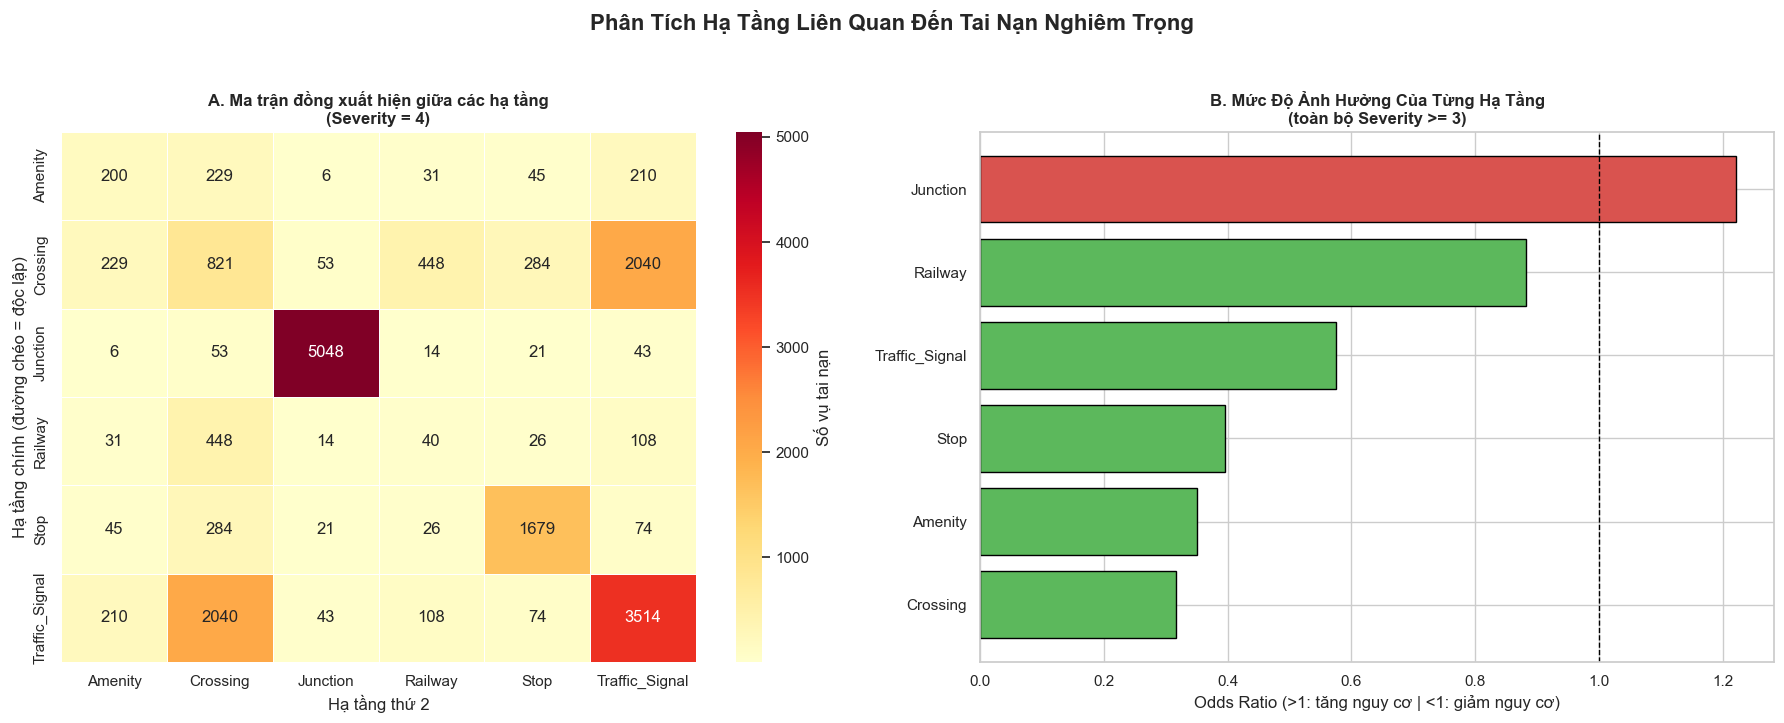

       Ha_tang  Odds_Ratio     Chi2   p_value  Cramér's_V
      Crossing    0.315738 11893.68  0.00e+00      0.0633
       Amenity    0.350017  1261.03 3.33e-276      0.0206
          Stop    0.396225  2488.92  0.00e+00      0.0289
Traffic_Signal    0.574369  4097.03  0.00e+00      0.0371
       Railway    0.881730    23.91  1.01e-06      0.0028
      Junction    1.222066   614.11 1.43e-135      0.0144


In [12]:


# ============================================================
# PHẦN A: Chuẩn bị dữ liệu
# ============================================================
df_severe = df[df['Severity'] == 4].copy()
infra_cols = ['Amenity', 'Crossing', 'Junction', 'Railway', 'Stop', 'Traffic_Signal']

for col in infra_cols:
    if df_severe[col].dtype != bool:
        df_severe[col] = df_severe[col].astype(bool)

# Ma trận đồng xuất hiện
matrix = pd.DataFrame(0, index=infra_cols, columns=infra_cols)
for i in infra_cols:
    for j in infra_cols:
        if i == j:
            other_cols = [c for c in infra_cols if c != i]
            mask = (df_severe[i] == True) & (df_severe[other_cols].sum(axis=1) == 0)
            matrix.loc[i, j] = mask.sum()
        else:
            mask = (df_severe[i] == True) & (df_severe[j] == True)
            matrix.loc[i, j] = mask.sum()

# Chi-square + Odds Ratio cho từng hạ tầng (trên toàn bộ df, Severity >= 3)
df['Is_Severe'] = (df['Severity'] >= 3)
odds_ratio_results = []
for col in infra_cols:
    ct = pd.crosstab(df[col], df['Is_Severe'])
    chi2, p, dof, expected = chi2_contingency(ct)
    a = ct.loc[True, True] if True in ct.index and True in ct.columns else 0
    b = ct.loc[True, False] if True in ct.index and False in ct.columns else 0
    c = ct.loc[False, True] if False in ct.index and True in ct.columns else 0
    d = ct.loc[False, False] if False in ct.index and False in ct.columns else 0
    odds_ratio = (a * d) / (b * c) if (b * c) != 0 else np.nan
    n = ct.sum().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    odds_ratio_results.append({'Ha_tang': col, 'Odds_Ratio': odds_ratio,
                                'Chi2': round(chi2, 2), 'p_value': f"{p:.2e}",
                                "Cramér's_V": round(cramers_v, 4)})

odds_df = pd.DataFrame(odds_ratio_results).sort_values('Odds_Ratio', ascending=True)

# ============================================================
# PHẦN B: Gộp thành 1 figure duy nhất, bố cục 1x2
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Biểu đồ 1: Heatmap ma trận đồng xuất hiện ---
sns.heatmap(matrix, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5,
            linecolor='white', cbar_kws={'label': 'Số vụ tai nạn'}, ax=axes[0])
axes[0].set_title('A. Ma trận đồng xuất hiện giữa các hạ tầng\n(Severity = 4)', fontweight='bold')
axes[0].set_xlabel('Hạ tầng thứ 2')
axes[0].set_ylabel('Hạ tầng chính (đường chéo = độc lập)')

# --- Biểu đồ 2: Odds Ratio ---
colors = ['#D9534F' if x > 1 else '#5CB85C' for x in odds_df['Odds_Ratio']]
axes[1].barh(odds_df['Ha_tang'], odds_df['Odds_Ratio'], color=colors, edgecolor='black')
axes[1].axvline(x=1, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Odds Ratio (>1: tăng nguy cơ | <1: giảm nguy cơ)')
axes[1].set_title('B. Mức Độ Ảnh Hưởng Của Từng Hạ Tầng\n(toàn bộ Severity >= 3)', fontweight='bold')

fig.suptitle('Phân Tích Hạ Tầng Liên Quan Đến Tai Nạn Nghiêm Trọng', fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

# ============================================================
# In bảng kiểm định thống kê gọn
# ============================================================
print(odds_df[['Ha_tang', 'Odds_Ratio', 'Chi2', 'p_value', "Cramér's_V"]].to_string(index=False))

**Nhận xét:** Kết quả Odds Ratio cho thấy chỉ duy nhất **Junction** làm tăng nguy cơ nghiêm
trọng (OR=1.22), trong khi 5 hạ tầng còn lại đều có tác dụng bảo vệ (OR<1) — mạnh nhất là
Crossing (OR=0.32) và Stop (OR=0.40). Đáng chú ý, **Traffic_Signal** tuy vẫn có tác dụng bảo
vệ (OR=0.57) nhưng yếu hơn hẳn Crossing/Stop, và trong nhóm tai nạn nghiêm trọng nhất
(Severity=4) lại thường xuất hiện cùng Crossing — cho thấy hiệu quả thực tế của đèn tín hiệu
tại các điểm giao cắt có thể chưa tương xứng với vai trò kiểm soát giao thông của nó.

**Kết luận:** Ưu tiên rà soát Junction (yếu tố duy nhất làm tăng nguy cơ) trước; đồng thời
đánh giá lại hiệu quả vận hành thực tế của Traffic_Signal (thời gian đèn, khả năng quan sát,
tuân thủ) tại các điểm Crossing, vì mức bảo vệ hiện tại thấp hơn kỳ vọng so với các biện pháp
kiểm soát khác.

## 8. Câu hỏi 7 — Top điểm đen cần ưu tiên can thiệp trước mùa mưa bão
Tổng hợp 3 yếu tố (tổng số vụ, tỷ lệ nghiêm trọng, tỷ lệ liên quan thời tiết xấu) thành một **điểm ưu tiên (Priority Score)** có trọng số, để xếp hạng các khu vực cần can thiệp trước mùa mưa bão.


=== Xác nhận thứ tự xếp hạng theo Priority Score ===
                     Location_Key  Total_Accidents  Severe_Rate_%  Wilson_Severe_Rate_%  Weather_Related_Rate_%  Priority_Score
        Springfield, Sangamon, IL              120          94.17                 88.45                   21.67          0.5230
               Lincoln, Logan, IL               41          97.56                 87.40                   29.27          0.5051
         Champaign, Champaign, IL               92          93.48                 86.49                   17.39          0.4900
                Chicago, Cook, IL             9042          53.20                 52.17                   12.70          0.4864
            Urbana, Champaign, IL               40          95.00                 83.50                   25.00          0.4722
         Effingham, Effingham, IL               47          93.62                 82.84                   21.28          0.4624
            Tinley Park, Will, IL              139

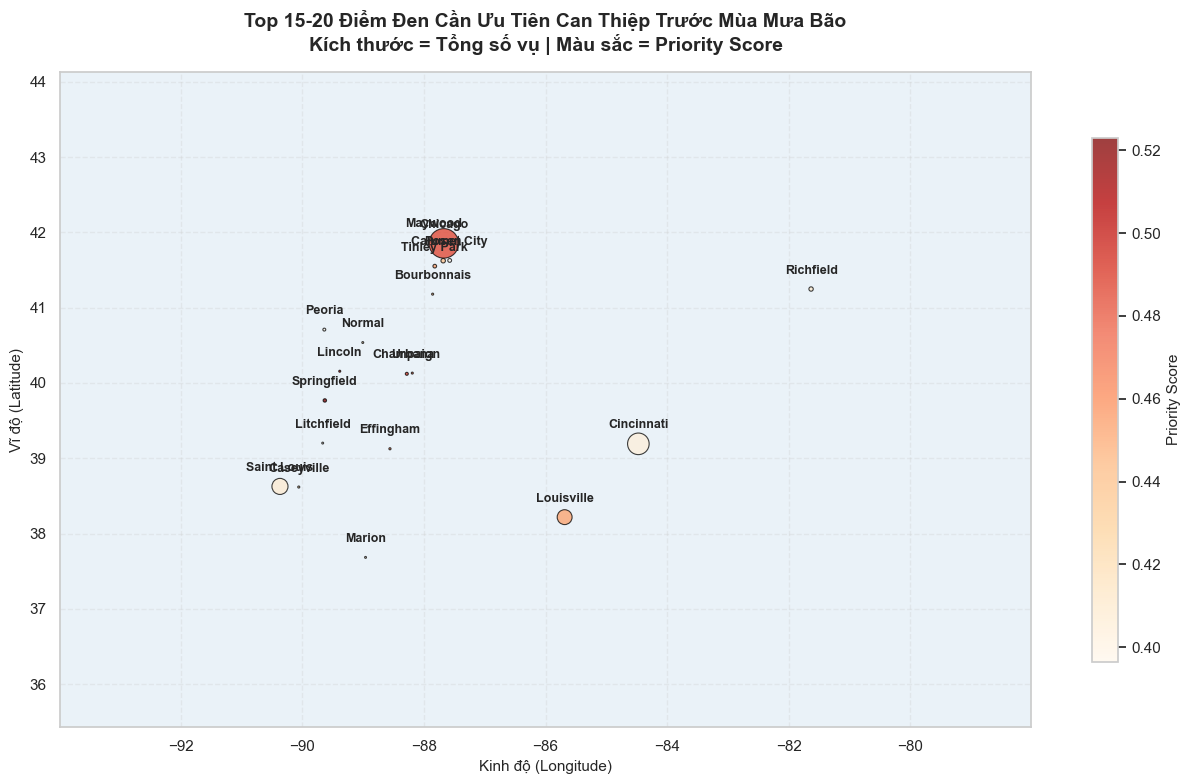

In [ ]:

df['Location_Key'] = df['City'].astype(str) + ', ' + df['County'].astype(str) + ', ' + df['State'].astype(str)


hotspot = df.groupby('Location_Key').agg(
    Total_Accidents=('ID', 'count'),
    Severe_Count=('Severity', lambda x: (x >= 3).sum()),
    Weather_Related_Count=('Is_Adverse_Weather', 'sum'),
    Avg_Lat=('Start_Lat', 'mean'),
    Avg_Lng=('Start_Lng', 'mean')
).reset_index()

hotspot['Severe_Rate_%'] = (hotspot['Severe_Count'] / hotspot['Total_Accidents'] * 100).round(2)
hotspot['Weather_Related_Rate_%'] = (hotspot['Weather_Related_Count'] / hotspot['Total_Accidents'] * 100).round(2)


def wilson_lower_bound(pos, n, confidence=0.95):
    if n == 0:
        return 0
    z = sst.norm.ppf(1 - (1 - confidence) / 2)
    phat = pos / n
    denom = 1 + z**2 / n
    centre = phat + z**2 / (2 * n)
    margin = z * np.sqrt((phat * (1 - phat) + z**2 / (4 * n)) / n)
    return (centre - margin) / denom

hotspot['Wilson_Severe_Rate_%'] = hotspot.apply(
    lambda r: wilson_lower_bound(r['Severe_Count'], r['Total_Accidents']) * 100, axis=1
).round(2)


scaler = MinMaxScaler()
filtered_hotspot = hotspot[hotspot['Total_Accidents'] >= 30].copy()

filtered_hotspot['log_Total_Accidents'] = np.log1p(filtered_hotspot['Total_Accidents'])

features = ['log_Total_Accidents', 'Wilson_Severe_Rate_%', 'Weather_Related_Rate_%']
scaled_values = scaler.fit_transform(filtered_hotspot[features])

w_volume, w_severe, w_weather = 0.3, 0.4, 0.3
filtered_hotspot['Priority_Score'] = (
    scaled_values[:, 0] * w_volume +
    scaled_values[:, 1] * w_severe +
    scaled_values[:, 2] * w_weather
).round(4)

top_priority_hotspots = filtered_hotspot.sort_values('Priority_Score', ascending=False).head(20)

# ============================================================
# In riêng các cột cần thiết để xác nhận đúng thứ tự Priority Score
# ============================================================
print("\n=== Xác nhận thứ tự xếp hạng theo Priority Score ===")
print(top_priority_hotspots[['Location_Key', 'Total_Accidents', 'Severe_Rate_%',
                              'Wilson_Severe_Rate_%', 'Weather_Related_Rate_%',
                              'Priority_Score']].to_string(index=False))

fig, ax = plt.subplots(figsize=(13, 8))

scatter = ax.scatter(
    top_priority_hotspots['Avg_Lng'],
    top_priority_hotspots['Avg_Lat'],
    s=top_priority_hotspots['Total_Accidents'] / 20,   # tăng hệ số chia nhỏ lại vì giờ zoom gần hơn, bubble cần to hơn tương đối
    c=top_priority_hotspots['Priority_Score'],
    cmap='OrRd',
    alpha=0.75,
    edgecolors='black',
    linewidths=0.8,
    zorder=3
)

# Ghi tên TẤT CẢ các điểm (vì giờ đã zoom gần, đủ chỗ hiển thị hết, không chỉ top 10)
for _, row in top_priority_hotspots.iterrows():
    ax.annotate(
        row['Location_Key'].split(',')[0],
        (row['Avg_Lng'], row['Avg_Lat']),
        fontsize=9, fontweight='bold', ha='center', va='bottom',
        xytext=(0, 9), textcoords='offset points'
    )

# ============================================================
# Tự động co giãn khung theo đúng phạm vi dữ liệu + đệm biên (padding)
# ============================================================
lat_min, lat_max = top_priority_hotspots['Avg_Lat'].min(), top_priority_hotspots['Avg_Lat'].max()
lng_min, lng_max = top_priority_hotspots['Avg_Lng'].min(), top_priority_hotspots['Avg_Lng'].max()

lat_padding = (lat_max - lat_min) * 0.3 + 1   # +1 độ tối thiểu để không quá sát
lng_padding = (lng_max - lng_min) * 0.3 + 1

ax.set_xlim(lng_min - lng_padding, lng_max + lng_padding)
ax.set_ylim(lat_min - lat_padding, lat_max + lat_padding)
ax.set_facecolor('#eaf2f8')

cbar = plt.colorbar(scatter, ax=ax, shrink=0.8)
cbar.set_label('Priority Score', fontsize=11)

ax.set_title('Top 15-20 Điểm Đen Cần Ưu Tiên Can Thiệp Trước Mùa Mưa Bão\n'
             'Kích thước = Tổng số vụ | Màu sắc = Priority Score',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Kinh độ (Longitude)', fontsize=11)
ax.set_ylabel('Vĩ độ (Latitude)', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.3, zorder=0)

plt.tight_layout()
plt.show()



**Nhận xét:** Sau khi tính Priority Score có điều chỉnh Wilson Score và log-transform, kết quả
cho thấy các **thị trấn nhỏ có tỷ lệ nghiêm trọng gần như tuyệt đối** lại được xếp ưu tiên cao
nhất — dẫn đầu là Springfield, IL (Priority Score 0.523, tỷ lệ nghiêm trọng 94.17% dù chỉ 120
vụ), theo sau là Lincoln (0.505, 97.56%) và Champaign (0.490, 93.48%). Chicago — dù có khối
lượng tai nạn lớn nhất trong danh sách (9,042 vụ) — chỉ xếp thứ 4 (0.486), do tỷ lệ nghiêm trọng
tương đối thấp hơn nhiều (53.20%) so với các thị trấn nhỏ.

Điều này phản ánh đúng thiết kế trọng số của Priority Score: tỷ lệ nghiêm trọng (Wilson Score)
được gán trọng số cao nhất (40%), nên các khu vực tuy quy mô nhỏ nhưng có tỷ lệ tai nạn nặng gần
như tuyệt đối vẫn được ưu tiên hơn khu vực khối lượng lớn nhưng tỷ lệ nghiêm trọng vừa phải.
Toàn bộ 20 điểm đen hàng đầu đều tập trung ở khu vực Illinois và các bang lân cận
(Kentucky - Louisville, Ohio - Cincinnati/Richfield, Missouri - Saint Louis), cho thấy đây là
vùng cần ưu tiên khảo sát trước mùa mưa bão.

**Lưu ý khi diễn giải:** Với các thị trấn có N nhỏ (Lincoln n=41, Urbana n=40, Marion n=36), dù
đã dùng Wilson Score để giảm bớt sai lệch do mẫu nhỏ, tỷ lệ nghiêm trọng vẫn có thể biến động
mạnh nếu chỉ vài vụ thay đổi. Nên xem đây là danh sách ưu tiên **khảo sát thực địa**, không phải
kết luận cuối cùng về mức độ nguy hiểm tuyệt đối.